# Outlier analysis (topic = −1)

Documents assigned to topic **-1** by HDBSCAN are *noise* — they did not
fall inside any dense cluster.  This notebook profiles those outliers to
understand **why** the outlier rate is high and whether any of them could
reasonably be reassigned.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

SEED = 42
np.random.seed(SEED)

ASSETS_DIR     = os.path.join('..', 'assets')
EMBEDDINGS_DIR = os.path.join(ASSETS_DIR, 'embeddings')
MODELS_DIR     = os.path.join(ASSETS_DIR, 'topic_models')

## 1. Load data

In [2]:
# ── Embeddings & corpus texts ────────────────────────────────────────────────
papers_emb = np.load(os.path.join(EMBEDDINGS_DIR, 'papers_embeddings.npy'))
teams_emb  = np.load(os.path.join(EMBEDDINGS_DIR, 'teams_embeddings.npy'))

papers_corpus = pd.read_csv(os.path.join(EMBEDDINGS_DIR, 'papers_corpus.txt'), sep='\t')
teams_corpus  = pd.read_csv(os.path.join(EMBEDDINGS_DIR, 'teams_corpus.txt'), sep='\t')

# ── Topic assignments ─────────────────────────────────────────────────────────
papers_topics = pd.read_csv(os.path.join(MODELS_DIR, 'papers_doc_topics.txt'), sep='\t')
teams_topics  = pd.read_csv(os.path.join(MODELS_DIR, 'teams_doc_topics.txt'), sep='\t')

# ── Original metadata ─────────────────────────────────────────────────────────
papers_meta = pd.read_csv(os.path.join(ASSETS_DIR, 'synbio_openalex.txt'), sep='\t')
teams_meta  = pd.read_csv(os.path.join(ASSETS_DIR, 'igem.txt'), sep='\t')

# Merge topic label into metadata
papers = papers_meta.merge(papers_topics, on='id', how='inner')
teams  = teams_meta.merge(teams_topics, on='UT', how='inner')

print(f'Papers: {len(papers):,}  |  Teams: {len(teams):,}')

Papers: 33,625  |  Teams: 4,548


## 2. Outlier overview

In [3]:
def outlier_summary(df, name, year_col):
    """Print basic outlier statistics."""
    total     = len(df)
    outliers  = (df['topic'] == -1).sum()
    assigned  = total - outliers
    print(f'── {name} {"─" * (50 - len(name))}')
    print(f'  Total docs   : {total:>8,}')
    print(f'  Assigned     : {assigned:>8,}  ({100 * assigned / total:.1f}%)')
    print(f'  Outliers (−1): {outliers:>8,}  ({100 * outliers / total:.1f}%)')
    print(f'  Year range   : {df[year_col].min():.0f} – {df[year_col].max():.0f}')
    print()

outlier_summary(papers, 'Papers', 'publication_year')
outlier_summary(teams,  'Teams',  'PY')

── Papers ────────────────────────────────────────────
  Total docs   :   33,625
  Assigned     :   17,671  (52.6%)
  Outliers (−1):   15,954  (47.4%)
  Year range   : 1950 – 2025

── Teams ─────────────────────────────────────────────
  Total docs   :    4,548
  Assigned     :    2,721  (59.8%)
  Outliers (−1):    1,827  (40.2%)
  Year range   : 2009 – 2025



## 3. Outlier rate by year

If outliers concentrate in certain years the data may simply be sparse
or the vocabulary may be different in those periods.

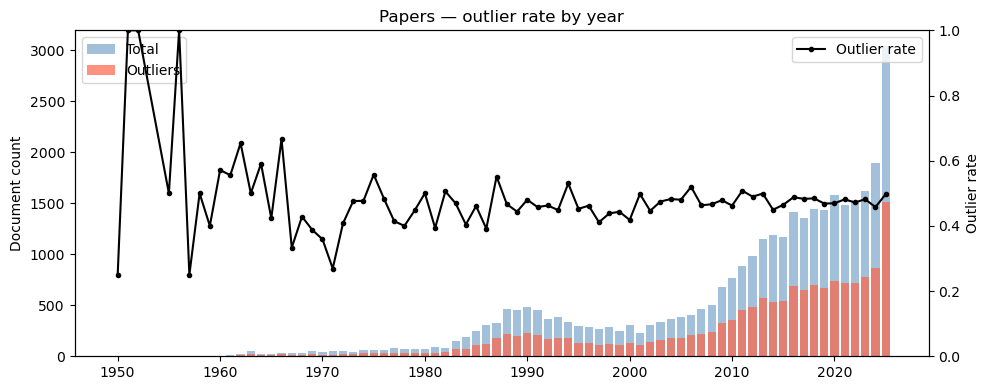

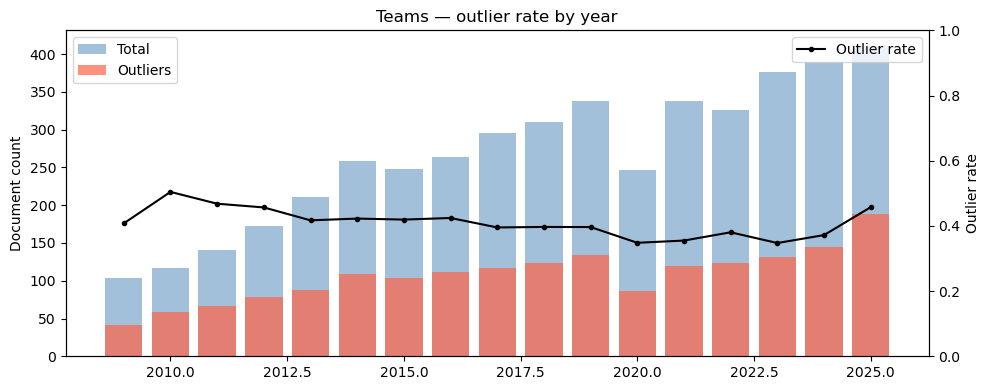

In [4]:
def plot_outlier_rate_by_year(df, year_col, title):
    grouped = df.groupby(year_col)['topic'].agg(
        total='count',
        outliers=lambda s: (s == -1).sum(),
    )
    grouped['rate'] = grouped['outliers'] / grouped['total']

    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax1.bar(grouped.index, grouped['total'], color='steelblue', alpha=0.5, label='Total')
    ax1.bar(grouped.index, grouped['outliers'], color='tomato', alpha=0.7, label='Outliers')
    ax1.set_ylabel('Document count')
    ax1.legend(loc='upper left')

    ax2 = ax1.twinx()
    ax2.plot(grouped.index, grouped['rate'], 'k-o', ms=3, label='Outlier rate')
    ax2.set_ylabel('Outlier rate')
    ax2.set_ylim(0, 1)
    ax2.legend(loc='upper right')

    ax1.set_title(title)
    plt.tight_layout()
    plt.show()

plot_outlier_rate_by_year(papers, 'publication_year', 'Papers — outlier rate by year')
plot_outlier_rate_by_year(teams, 'PY', 'Teams — outlier rate by year')

## 4. Text length: outliers vs assigned

Short or empty abstracts often end up as outliers because their
embeddings carry little signal.

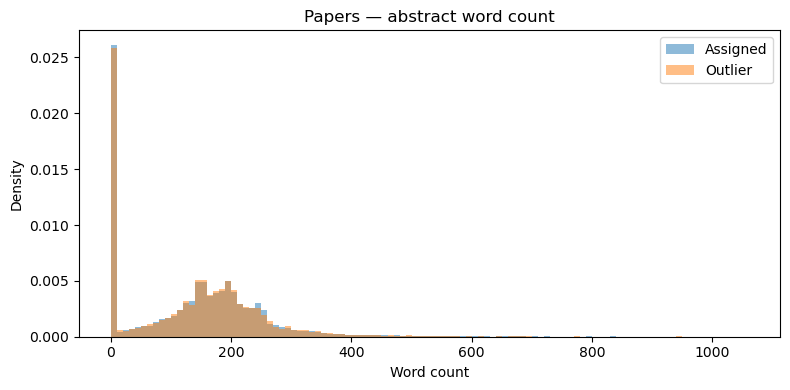

  ≤10 words  →  outliers: 4,090 (25.6%)  |  assigned: 4,584 (25.9%)
  ≤20 words  →  outliers: 4,175 (26.2%)  |  assigned: 4,660 (26.4%)
  ≤50 words  →  outliers: 4,513 (28.3%)  |  assigned: 5,050 (28.6%)



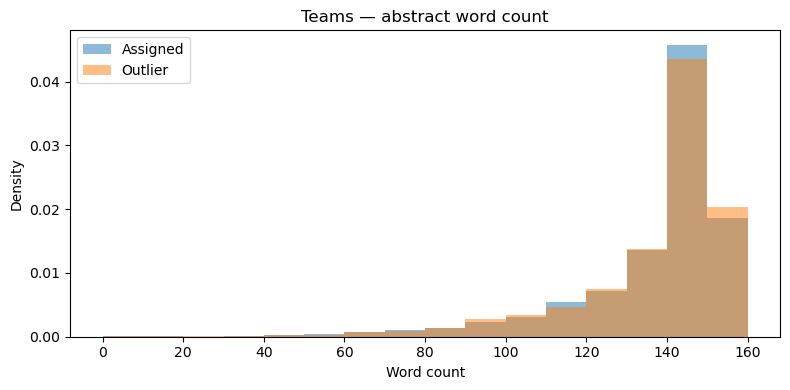

  ≤10 words  →  outliers: 2 (0.1%)  |  assigned: 2 (0.1%)
  ≤20 words  →  outliers: 3 (0.2%)  |  assigned: 4 (0.1%)
  ≤50 words  →  outliers: 11 (0.6%)  |  assigned: 15 (0.6%)


In [5]:
def plot_text_length(df, text_col, title):
    df = df.copy()
    df['_text_len'] = df[text_col].fillna('').str.split().str.len()
    outlier = df.loc[df['topic'] == -1, '_text_len']
    assigned = df.loc[df['topic'] != -1, '_text_len']

    fig, ax = plt.subplots(figsize=(8, 4))
    bins = np.arange(0, max(outlier.quantile(0.99), assigned.quantile(0.99)) + 20, 10)
    ax.hist(assigned, bins=bins, alpha=0.5, density=True, label='Assigned')
    ax.hist(outlier, bins=bins, alpha=0.5, density=True, label='Outlier')
    ax.set_xlabel('Word count')
    ax.set_ylabel('Density')
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

    # Short-text stats
    for threshold in [10, 20, 50]:
        n_short_out = (outlier <= threshold).sum()
        n_short_asg = (assigned <= threshold).sum()
        print(f'  ≤{threshold} words  →  outliers: {n_short_out:,} ({100*n_short_out/len(outlier):.1f}%)'
              f'  |  assigned: {n_short_asg:,} ({100*n_short_asg/len(assigned):.1f}%)')

plot_text_length(papers, 'abstract', 'Papers — abstract word count')
print()
plot_text_length(teams, 'AB', 'Teams — abstract word count')

## 5. Language distribution (papers only)

Non-English papers encoded with an English sentence-transformer may
produce out-of-distribution embeddings that cluster poorly.

In [6]:
if 'language' in papers.columns:
    lang = papers.groupby(['language', papers['topic'].apply(
        lambda t: 'outlier' if t == -1 else 'assigned'
    )]).size().unstack(fill_value=0)
    lang['total'] = lang.sum(axis=1)
    lang = lang.sort_values('total', ascending=False).head(15)
    lang['outlier_rate'] = lang['outlier'] / lang['total']
    display(lang)

topic,assigned,outlier,total,outlier_rate
language,,,,
en,17164,15430,32594,0.473400
fr,35,37,72,0.513889
de,27,41,68,0.602941
es,32,15,47,0.319149
ko,26,15,41,0.365854
pt,16,17,33,0.515152
zh,17,11,28,0.392857
ru,12,12,24,0.500000
ca,4,6,10,0.600000


## 6. Embedding distance to nearest cluster centroid

For each outlier document we measure the cosine distance to the nearest
cluster centroid.  Documents close to a centroid might be recoverable;
truly isolated documents are genuine noise.

── Papers ─────────────────────────────────────────


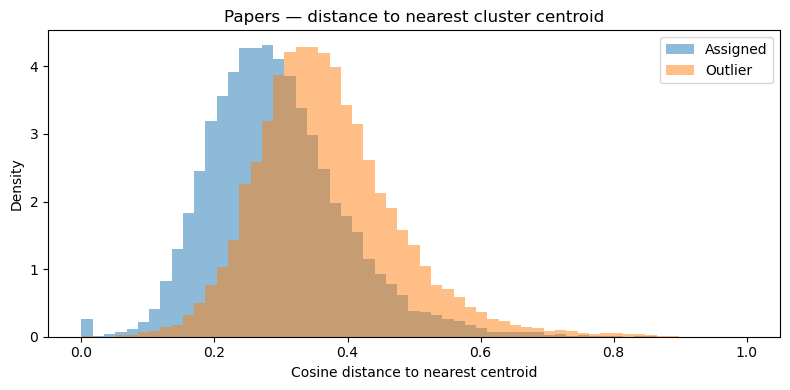

  Papers outlier distance quantiles:
    10%: 0.2481
    25%: 0.2975
    50%: 0.3568
    75%: 0.4251
    90%: 0.5017
  Papers assigned distance quantiles:
    10%: 0.1755
    25%: 0.2222
    50%: 0.2820
    75%: 0.3490
    90%: 0.4227

  Outliers closer than median assigned distance (0.2820): 3,072 / 15,954 (19.3%)

── Teams ──────────────────────────────────────────


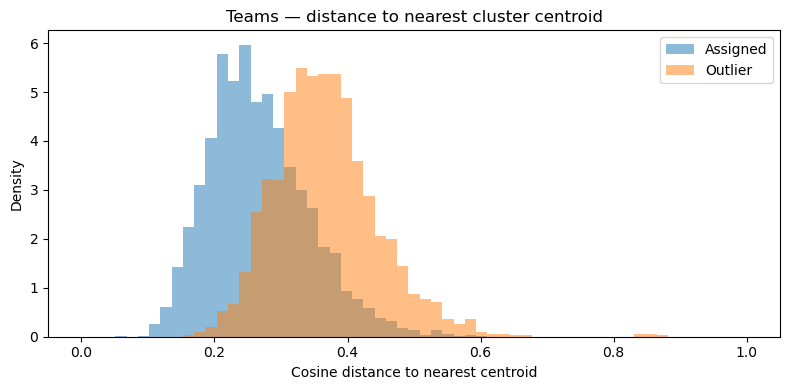

  Teams outlier distance quantiles:
    10%: 0.2740
    25%: 0.3163
    50%: 0.3626
    75%: 0.4114
    90%: 0.4690
  Teams assigned distance quantiles:
    10%: 0.1765
    25%: 0.2120
    50%: 0.2573
    75%: 0.3132
    90%: 0.3668

  Outliers closer than median assigned distance (0.2573): 98 / 1,827 (5.4%)


In [7]:
def nearest_centroid_analysis(embeddings, topics_arr, name):
    topics_arr = np.array(topics_arr)
    assigned_mask = topics_arr != -1
    outlier_mask  = topics_arr == -1

    # Compute cluster centroids (mean embedding per topic)
    unique_topics = np.unique(topics_arr[assigned_mask])
    centroids = np.vstack([
        embeddings[topics_arr == t].mean(axis=0) for t in unique_topics
    ])

    # Cosine distance from every outlier to every centroid
    dists_outliers  = cdist(embeddings[outlier_mask], centroids, metric='cosine').min(axis=1)
    dists_assigned  = cdist(embeddings[assigned_mask], centroids, metric='cosine').min(axis=1)

    fig, ax = plt.subplots(figsize=(8, 4))
    bins = np.linspace(0, 1, 60)
    ax.hist(dists_assigned, bins=bins, alpha=0.5, density=True, label='Assigned')
    ax.hist(dists_outliers, bins=bins, alpha=0.5, density=True, label='Outlier')
    ax.set_xlabel('Cosine distance to nearest centroid')
    ax.set_ylabel('Density')
    ax.set_title(f'{name} — distance to nearest cluster centroid')
    ax.legend()
    plt.tight_layout()
    plt.show()

    # Quantiles
    print(f'  {name} outlier distance quantiles:')
    for q in [0.10, 0.25, 0.50, 0.75, 0.90]:
        print(f'    {q:.0%}: {np.quantile(dists_outliers, q):.4f}')
    print(f'  {name} assigned distance quantiles:')
    for q in [0.10, 0.25, 0.50, 0.75, 0.90]:
        print(f'    {q:.0%}: {np.quantile(dists_assigned, q):.4f}')

    # How many outliers are closer than the median assigned distance?
    median_asg = np.median(dists_assigned)
    recoverable = (dists_outliers <= median_asg).sum()
    print(f'\n  Outliers closer than median assigned distance ({median_asg:.4f}): '
          f'{recoverable:,} / {outlier_mask.sum():,} ({100*recoverable/outlier_mask.sum():.1f}%)')

    return dists_outliers, dists_assigned

print('── Papers ─────────────────────────────────────────')
papers_dists_out, papers_dists_asg = nearest_centroid_analysis(
    papers_emb, papers_topics['topic'].values, 'Papers'
)
print()
print('── Teams ──────────────────────────────────────────')
teams_dists_out, teams_dists_asg = nearest_centroid_analysis(
    teams_emb, teams_topics['topic'].values, 'Teams'
)

## 7. Citation profile of outliers (papers)

Low-citation outliers may be marginal or off-topic. High-citation
outliers are worth investigating further.

,count,mean,std,min,25%,50%,75%,max
Assigned,17671.0,33.861072,98.612240,0.0,0.0,8.0,32.0,3532.0
Outlier,15954.0,30.528143,91.677322,0.0,0.0,7.0,28.0,2847.0


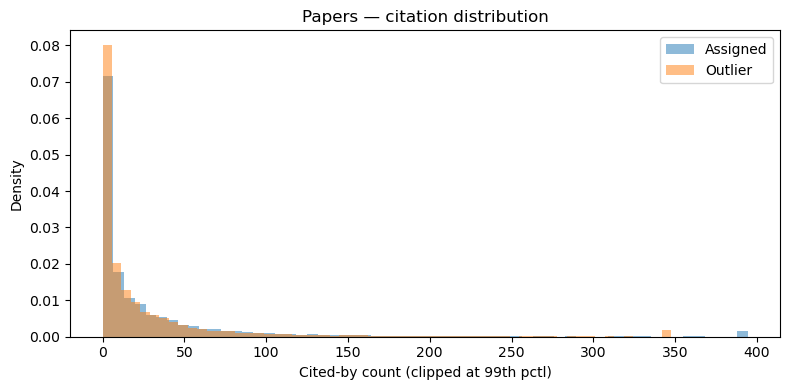

In [8]:
papers['_is_outlier'] = papers['topic'] == -1

cite_stats = papers.groupby('_is_outlier')['cited_by_count'].describe()
cite_stats.index = ['Assigned', 'Outlier']
display(cite_stats)

fig, ax = plt.subplots(figsize=(8, 4))
for label, grp in papers.groupby('_is_outlier'):
    vals = grp['cited_by_count'].clip(upper=grp['cited_by_count'].quantile(0.99))
    ax.hist(vals, bins=60, alpha=0.5, density=True, label='Outlier' if label else 'Assigned')
ax.set_xlabel('Cited-by count (clipped at 99th pctl)')
ax.set_ylabel('Density')
ax.set_title('Papers — citation distribution')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Concept overlap (papers)

OpenAlex assigns concept tags to each paper.  If outlier papers carry
very different concepts they may be genuinely off-topic.

In [9]:
def top_concepts(df, mask, n=20):
    concepts = df.loc[mask, 'concepts'].dropna().str.split(';').explode().str.strip()
    return concepts.value_counts().head(n)

out_concepts = top_concepts(papers, papers['topic'] == -1)
asg_concepts = top_concepts(papers, papers['topic'] != -1)

compare = pd.DataFrame({
    'rank_outliers': range(1, len(out_concepts) + 1),
    'concept': out_concepts.index,
    'count_outliers': out_concepts.values,
})
compare_asg = pd.DataFrame({
    'concept': asg_concepts.index,
    'rank_assigned': range(1, len(asg_concepts) + 1),
    'count_assigned': asg_concepts.values,
})
compare = compare.merge(compare_asg, on='concept', how='left')
display(compare)

,rank_outliers,concept,count_outliers,rank_assigned,count_assigned
0,1,Biology,9454,1,10171
1,2,Chemistry,5302,2,6024
2,3,Computational biology,4849,3,4746
3,4,Computer science,3946,5,3459
4,5,Synthetic biology,3527,6,3252
5,6,Gene,3364,4,3722
6,7,Biochemistry,3004,8,3060
7,8,Molecular biology,2912,7,3233
8,9,DNA,2835,10,2777
9,10,Genetics,2742,9,2941


## 9. Sample outlier documents

A random sample of outlier titles/abstracts helps build intuition about
what kind of documents are being left out.

In [12]:
print('── 10 random outlier PAPERS ────────────────────────────────────────')
sample_p = papers.loc[papers['topic'] == -1].sample(10, random_state=SEED)
for _, r in sample_p.iterrows():
    abstract = str(r.get('abstract', ''))[:200]
    print(f"  [{r['publication_year']:.0f}]  {r['title']}")
    print(f"         {abstract}...")
    print()

print('── 10 random outlier TEAMS ─────────────────────────────────────────')
sample_t = teams.loc[teams['topic'] == -1].sample(min(10, (teams['topic'] == -1).sum()), random_state=SEED)
for _, r in sample_t.iterrows():
    abstract = str(r.get('AB', ''))[:200]
    print(f"  [{r['PY']}]  {r['TI']}")
    print(f"         {abstract}...")
    print()

── 10 random outlier PAPERS ────────────────────────────────────────
  [2002]  Functional Activation of Heat Shock Factor and Hypoxia-Inducible Factor in the Kidney
         Renal ischemia is the result of a complex series of events, including decreases in oxygen supply (hypoxia) and the availability of cellular energy (ATP depletion). In this study, the functional activa...

  [2015]  Pancreatic stents for treatment of pancreatic duct dysruption syndrome: Analysis of outcomes and factors associated with therapeutic success
         nan...

  [2024]  Microbial cell factories for bio-based isoprenoid production to replace fossil resources
         nan...

  [2024]  Metabolic engineering of vitamin <scp>D<sub>3</sub></scp> in <i>Solanaceae</i> plants
         Vitamin D is a lipid-soluble sterol that plays an essential role in human health. Deficiency of this vitamin increases the risk of osteoporosis, hypertension, autoimmune diseases, infectious disease, ...

  [2016]  Isolation and cha

In [13]:
# ── Random sample of outlier teams (table view) ──────────────────────────────
sample_teams = (
    teams.loc[teams['topic'] == -1, ['UT', 'PY', 'TI', 'AB']]
    .sample(20, random_state=SEED)
    .reset_index(drop=True)
)
sample_teams['AB'] = sample_teams['AB'].fillna('').str[:300]
display(sample_teams)

,UT,PY,TI,AB
0,831,2012,Pest-busters,We are developing a modular synthetic system t...
1,5740,2025,Parkinson's disease treatment - new probiotic ...,Current treatments for Parkinson's Disease pri...
2,3854,2021,"Oil Together Painting, art from waste",How about converting a residual source into a ...
3,5342,2024,InfinityF∞ - an intranasal mRNA delivery syste...,InfinityF∞ delivers the mRNA sequence for fact...
4,4672,2023,SynLivPump: Harnessing Synthetic Biology for t...,Our team ventured to combat the prevalent glob...
5,1269,2014,Engineering an anaerobic indicator to monitor ...,Were seeking to create microbial fuel cells t...
6,2591,2018,"A Time-saving Machine"" for Genetic Screening i...",With rapid development of Molecular and Cellul...
7,2429,2017,Splice and Dice: Artificial Control of Alterna...,Alternative splicing is the eukaryotic mechani...
8,5916,2025,Team Imperial College London,The current model of meat production is enviro...
9,5076,2024,TamponX: creating a tampon prototype that prev...,"Toxic Shock Syndrome (TSS) is a rare, sometime..."


## Save orphan documents

In [16]:
REPORTS_DIR = os.path.join(ASSETS_DIR, 'reports')
os.makedirs(REPORTS_DIR, exist_ok=True)

# ── Orphan papers ─────────────────────────────────────────────────────────────
orphan_papers = papers.loc[papers['topic'] == -1, ['id', 'publication_year', 'title', 'abstract']].copy()
orphan_papers.to_csv(os.path.join(REPORTS_DIR, 'orphans_papers.tsv'), sep='\t', index=False)

# ── Orphan teams ──────────────────────────────────────────────────────────────
orphan_teams = teams.loc[teams['topic'] == -1, ['UT', 'PY', 'TI', 'AB']].copy()
orphan_teams.to_csv(os.path.join(REPORTS_DIR, 'orphans_teams.tsv'), sep='\t', index=False)

print(f'Saved {len(orphan_papers):,} orphan papers → {REPORTS_DIR}/orphans_papers.tsv')
print(f'Saved {len(orphan_teams):,} orphan teams  → {REPORTS_DIR}/orphans_teams.tsv')

Saved 15,954 orphan papers → ../assets/reports/orphans_papers.tsv
Saved 1,827 orphan teams  → ../assets/reports/orphans_teams.tsv


## 10. Summary

Collect the key findings into a single table.

In [17]:
def build_summary(df, emb, topic_col_vals, name, text_col, year_col):
    topics_arr = np.array(topic_col_vals)
    is_out = topics_arr == -1
    n_total = len(df)
    n_out   = is_out.sum()
    n_asg   = n_total - n_out

    # Text length
    wc = df[text_col].fillna('').str.split().str.len()
    short_out = (wc[is_out] <= 20).sum()

    # Distance to nearest centroid
    unique_topics = np.unique(topics_arr[~is_out])
    centroids = np.vstack([emb[topics_arr == t].mean(axis=0) for t in unique_topics])
    d_out = cdist(emb[is_out], centroids, metric='cosine').min(axis=1)
    d_asg = cdist(emb[~is_out], centroids, metric='cosine').min(axis=1)
    median_asg = np.median(d_asg)
    near_centroid = (d_out <= median_asg).sum()

    return {
        'dataset': name,
        'total': n_total,
        'assigned': n_asg,
        'outliers': n_out,
        'outlier_rate': f'{100*n_out/n_total:.1f}%',
        'outliers_≤20_words': f'{short_out:,} ({100*short_out/n_out:.1f}%)',
        'near_centroid': f'{near_centroid:,} ({100*near_centroid/n_out:.1f}%)',
        'far_from_clusters': f'{n_out - near_centroid:,} ({100*(n_out - near_centroid)/n_out:.1f}%)',
    }

summary = pd.DataFrame([
    build_summary(papers, papers_emb, papers_topics['topic'].values,
                  'Papers', 'abstract', 'publication_year'),
    build_summary(teams, teams_emb, teams_topics['topic'].values,
                  'Teams', 'AB', 'PY'),
]).set_index('dataset')

display(summary)

,total,assigned,outliers,outlier_rate,outliers_≤20_words,near_centroid,far_from_clusters
dataset,,,,,,,
Papers,33625,17671,15954,47.4%,"4,175 (26.2%)","3,072 (19.3%)","12,882 (80.7%)"
Teams,4548,2721,1827,40.2%,3 (0.2%),98 (5.4%),"1,729 (94.6%)"
